# **Calculation of the xT model**
---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1i64IO9H4edCf7HAZWR_SnS7VXYHdF3M2)

In this notebook I created a simple xT position-base model. I base my research on free resources [Soccermatics]( https://soccermatics.readthedocs.io/en/latest/#) course and [Karun Singh](https://karun.in/blog/expected-threat.html) blog post. Model calculation was base on [Hudl StatsBomb](https://github.com/statsbomb/open-data) free events data:

* *FA Women's Super League 2018/2019 and 2019/2020 seasons*

Model included only sucesfully passes, and corner as set pieces. Finally I calculate model transition matrix and saved it as a csv file. I will use this file to evaluation players in the next [*xT model evaluation*](https://github.com/MSI17819/Football_projects/blob/main/Code/xT_women_model_evaluation.ipynb)

---

### **1) Import needed packages and libraries**

In [ ]:
# Football pitch package instalation for Colab enviroment
%pip install mplsoccer -q
%pip install statsbombpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Import needed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Football packages
from mplsoccer import Pitch
from mplsoccer import VerticalPitch
from mplsoccer import FontManager
from mplsoccer import Sbopen
from statsbombpy import sb

#statistics package
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import binned_statistic_2d

# Import font type OpenSans
import matplotlib as mpl
mpl.font_manager.fontManager.addfont('/content/drive/MyDrive/OpenSans-Italic-VariableFont_wdth,wght[1].ttf')
plt.rcParams["font.family"] = "Open Sans"
warnings.filterwarnings("ignore")

### **2) xT model calculation**

I have divided the process into stages:

*   *data extraction and cleaning*
*   *data visualisation*
*   *calculation of the model transition matrix*
*   *xT model matrix storage*

#### **Data extraction and cleaning** ###

In [ ]:
def data_modf(competition_id, season_id, event_type):

  """Return pass event for all matches.

  Args:
      competition_id: data in int format from Hudl StatsBomb API.
      season_id: data in int format from Hudl StatsBomb API.
      event_type: data in str format

  Returns:
      df: df with xT value for each record.

  """
  # Instantiate a parser object from mplsoccer package
  parser = Sbopen()

  # Parse Women Euro 2022 match with parser object above
  df_match = parser.match(competition_id, season_id)
  match_ids = df_match.match_id.unique()

  # Create a df with all needed columns and event (I consider only passes) for our xT model evaluation
  all_pass_df = []
  cols = ['match_id', 'id', 'player_id','type_name', 'sub_type_name', 'player_name',
          'x', 'y', 'end_x', 'end_y', 'position_id', 'position_name','outcome_name'
          ]

  for match_id in match_ids:
      # Get passes events
      event = parser.event(match_id)[0]  # get the first dataframe (events) which has index = 0
      event = event.loc[event.type_name.isin([event_type]), cols].copy()
      all_pass_df.append(event)

  all_pass = pd.concat(all_pass_df)

  # Clean df only witch needed values
  val_list = ['Incomplete', 'Out', 'Pass Offside', 'Unknown',
              'Injury Clearance', 'Kick Off','Recovery', 'Goal Kick',
              'Throw-in', 'Free Kick', 'Interception'
              ]

  model = all_pass[~all_pass[["outcome_name", "sub_type_name"]].isin(val_list).any(axis=1)]
  # reset index
  model.reset_index(drop=True, inplace=True)

  return model

In [ ]:
# Passes and shots data extractions
# 37 is competition_id, 4 is season_id (2018/2019) and 42 is season_id (2019/2020)
# for Women Super League season 2018/2019 and 2019/2020
# according to Hudl StatsBomb database

pass_wsl_2018 = data_modf(37, 4, 'Pass')
pass_wsl_2019 = data_modf(37, 42, 'Pass')
shots_wsl_2018 = data_modf(37, 4, 'Shot')
shots_wsl_2019 = data_modf(37, 42, 'Shot')

In [ ]:
def data_prep_func(passes_season_2018=pass_wsl_2018, passes_season_2019=pass_wsl_2019, shots_season_2018=shots_wsl_2018, shots_season_2019=shots_wsl_2019):

  """Return df with data ready to vizualization.

  Args:
    passes_season_2018 (df): df contain all passes from football data
    passes_season_2019 (df): df contain all passes from football data
    shots_season_2018 (df): df contain all passes from football data
    shots_season_2019 (df): df contain all passes from football data

  Returns:
    df: df with clean data.

  """
  # One df for all passes
  all_passes = pd.concat([passes_season_2018, passes_season_2019])

  # Filter data to reach clean dataframe. Only succesfully consider
  values_list = ['Incomplete', 'Out', 'Pass Offside', 'Unknown', 'Injury Clearance', 'Kick Off','Recovery', 'Goal Kick', 'Throw-in', 'Free Kick', 'Interception']
  all_passes_clean = all_passes[~all_passes[["outcome_name", "type_name"]].isin(values_list).any(axis=1)]

  # Only passes in area of the pitch
  mask = ((all_passes_clean["x"] >= 0) & (all_passes_clean["end_x"] <= 120.0 ) & ((all_passes_clean["y"] >= 0.0) & \
   (all_passes_clean["y"] <= 80.0) & (all_passes_clean["end_y"] <= 80.0)))
  all_passes_clean = all_passes_clean.loc[mask, :]

  # One df with all shots
  all_shots = pd.concat([shots_season_2018, shots_season_2019])

  # Shots end location coordinates in seperate columns
  all_shots_clean = all_shots.query('sub_type_name == "Open Play"')
  all_goals_clean = all_shots_clean.query('outcome_name == "Goal"')

  return all_passes_clean, all_shots_clean, all_goals_clean

In [ ]:
all_passes_clean, all_shots_clean, all_goals_clean = data_prep_func(pass_wsl_2018, pass_wsl_2019, shots_wsl_2018, shots_wsl_2019)

#### **Data visualisation** ###

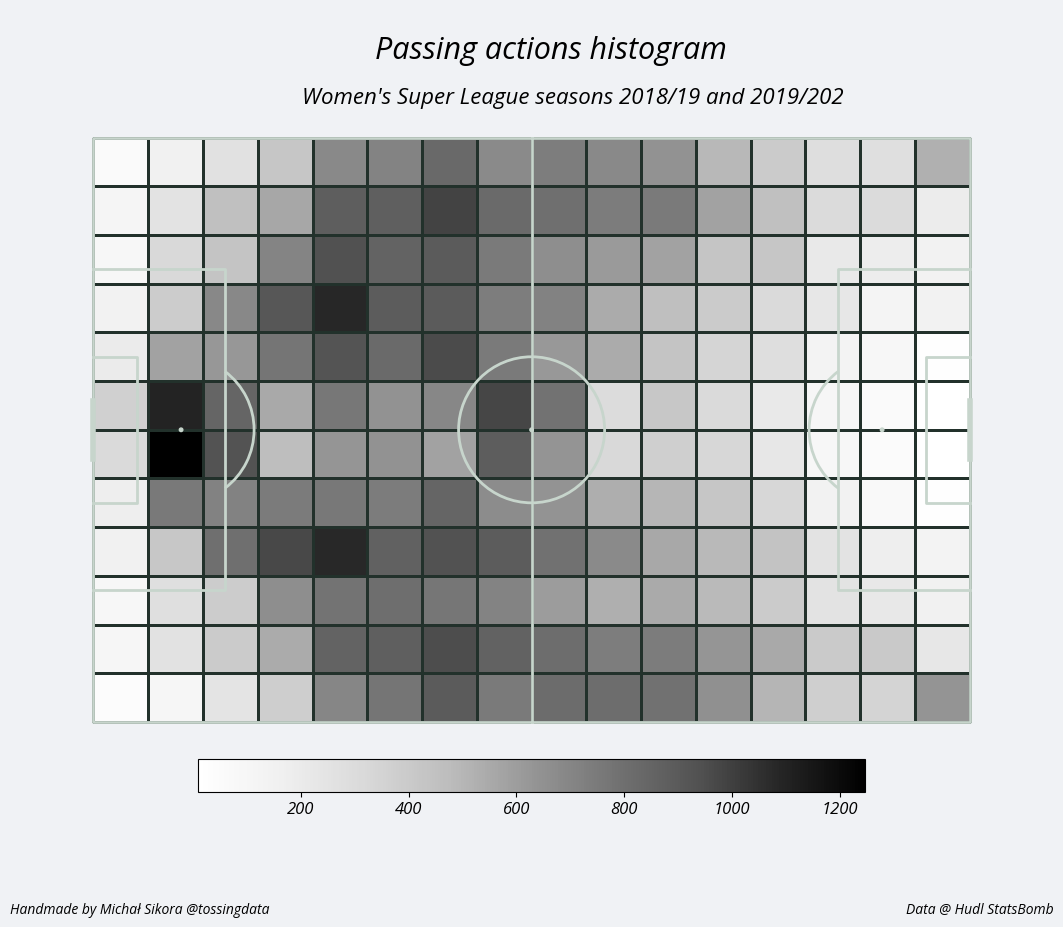

In [ ]:
# Passing actions vizualisation
pitch = Pitch(pitch_color='#f0f2f5',
              line_color='#c7d5cc',
              half = False,
              pitch_type='statsbomb',
              line_zorder=2,
              axis=False,
              tick=False
              )

women_passes_bin = pitch.bin_statistic(all_passes_clean.x, all_passes_clean.y, statistic='count', bins=(16, 12), normalize=False)

fig, axs = pitch.grid(grid_height=0.85,
                      title_height=0.11,
                      axis=False,
                      endnote_height=0.04,
                      title_space=0,
                      endnote_space=0
                      )

# Params
fig.set_facecolor('#f0f2f5')
edgecolor='#22312b'
alpha=0.6
c='#000000'
tick_font_size = 12

# Colorbar ticks params
params = {'xtick.color' : '#000000',
          'ytick.color' : '#000000'}

plt.rcParams.update(params)

move = pitch.bin_statistic(all_passes_clean.x, all_passes_clean.y, statistic='count', bins=(16, 12), normalize=False)
pcm = pitch.heatmap(move, cmap='Greys', edgecolor=edgecolor, ax=axs['pitch'])
cbar = plt.colorbar(pcm, ax=axs['pitch'], shrink=0.60, location='bottom', pad=0.01)
cbar.ax.tick_params(labelsize=tick_font_size)

# Title
axs['title'].text(x=0.35, y=0.50, s="Passing actions histogram", fontsize=20, c=c)

axs['title'].text(x=0.28, y=0.05, s="Women's Super League seasons 2018/19 and 2019/2020", fontsize=14, c=c)

# Endnote
axs['endnote'].text(0, 0., 'Handmade by Michał Sikora @tossingdata',
                    fontsize=10,
                    va='center',
                    ha='left',
                    c=c
                    )

axs['endnote'].text(1.0, 0., 'Data @ Hudl StatsBomb',
                    fontsize=10,
                    va='center',
                    ha='right',
                    c=c
                    )
plt.show()

# statitics pass to seperate argument
women_passes_bin = women_passes_bin['statistic']

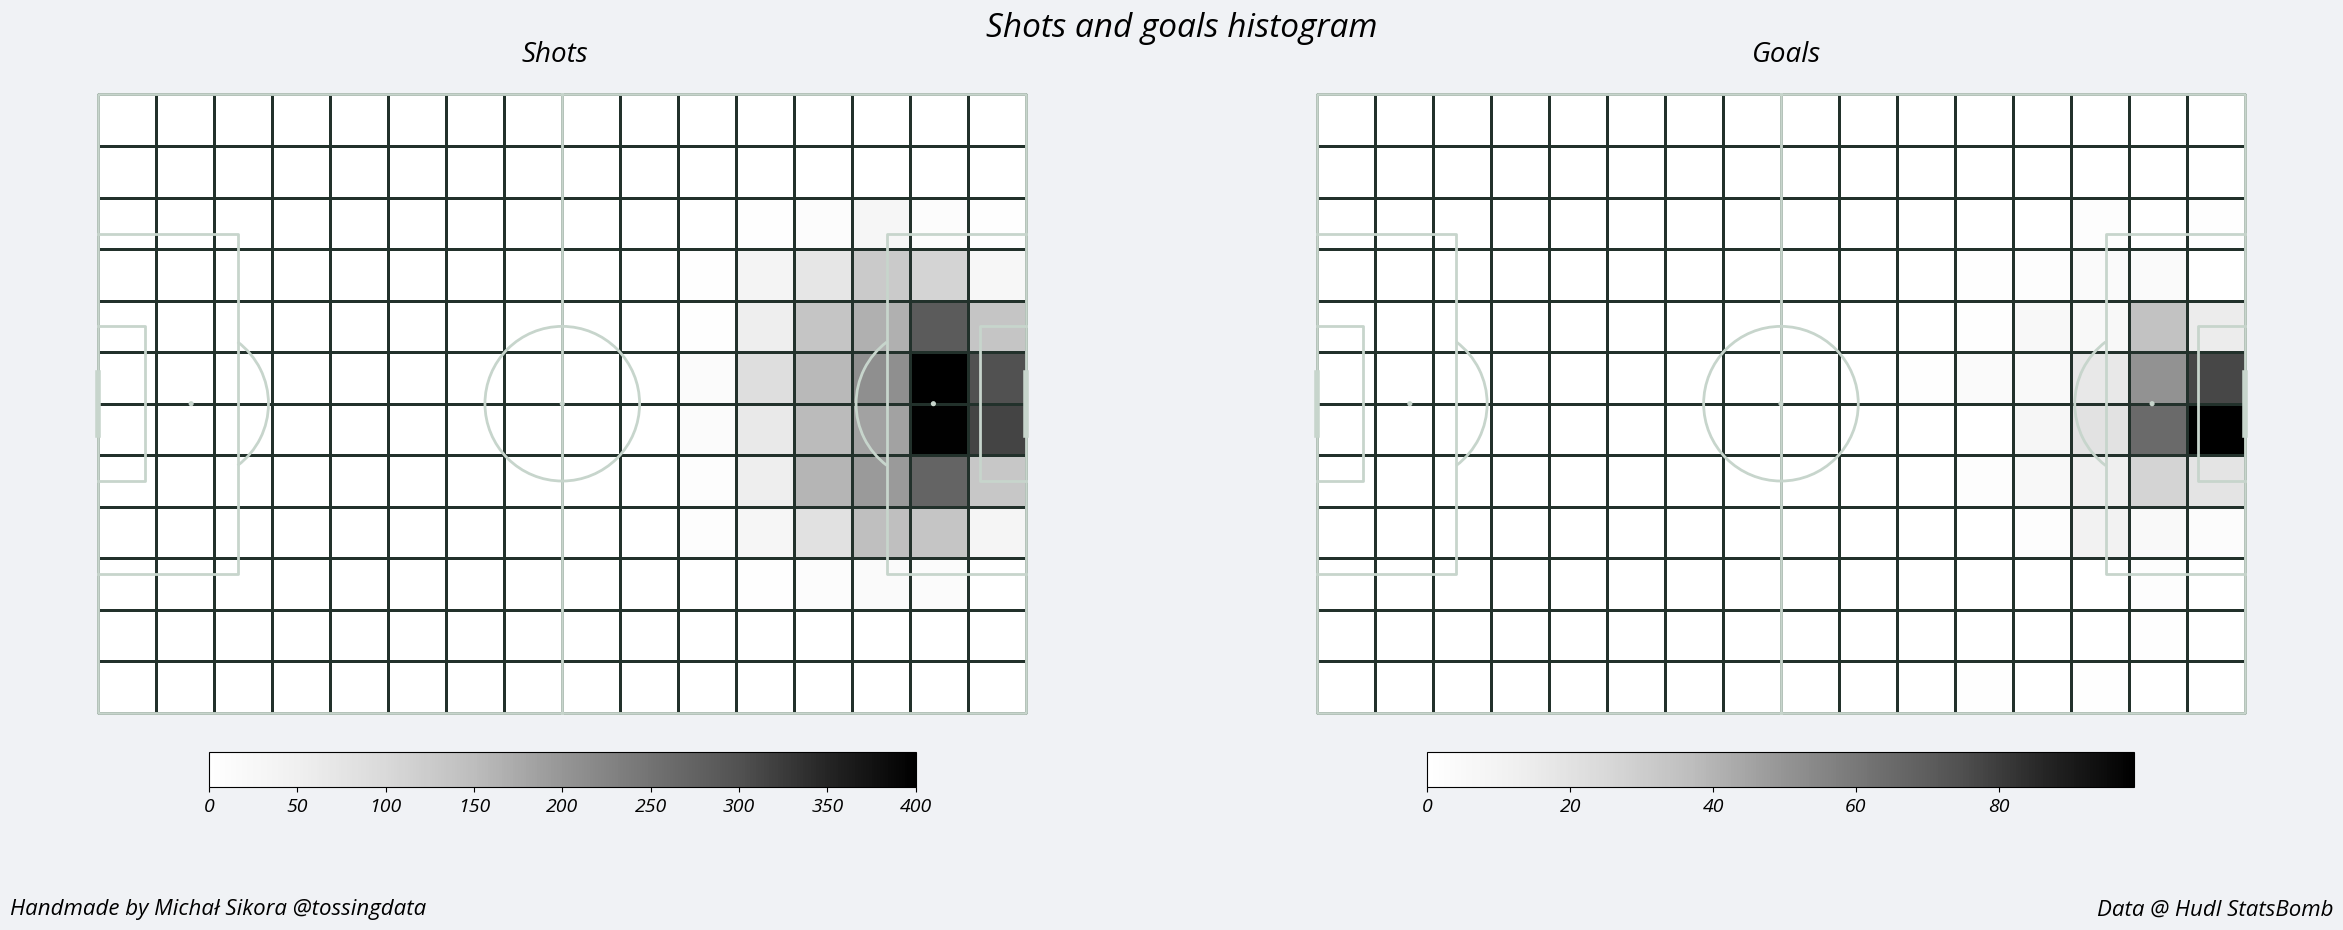

In [ ]:
# Shots and goals actions vizualisation
shots_goals_all = [all_shots_clean, all_goals_clean]

pitch = Pitch(pitch_color='#f0f2f5',
              line_color='#c7d5cc',
              half = False,
              pitch_type='statsbomb',
              line_zorder=2,
              axis=False,
              tick=False
              )

women_shots_bin = pitch.bin_statistic(all_shots_clean.x, all_shots_clean.y, statistic='count', bins=(16, 12), normalize=False)
women_goals_bin = pitch.bin_statistic(all_goals_clean.x, all_goals_clean.y, statistic='count', bins=(16, 12), normalize=False)

fig, axs = pitch.grid(ncols=2,
                      nrows=1,
                      grid_height=0.9,
                      title_height=0.06,
                      axis=False,
                      endnote_height=0.04,
                      title_space=0,
                      endnote_space=0
                      )

# Params
fig.set_facecolor('#f0f2f5')
edgecolor='#22312b'
color='#22312b'
alpha=0.6
c='#000000'
tick_font_size = 14

# Colorbar ticks params
params = {'xtick.color' : '#000000',
          'ytick.color' : '#000000'}

plt.rcParams.update(params)

for idx, ax in enumerate(axs['pitch'].flatten()):
  for i, ele in enumerate(shots_goals_all):
    if idx == i:
      move = pitch.bin_statistic(ele.x, ele.y, statistic='count', bins=(16, 12), normalize=False)
      pcm = pitch.heatmap(move, cmap='Greys', edgecolor=edgecolor, ax=ax)
      cbar = plt.colorbar(pcm, ax=ax, shrink=0.60, location='bottom', pad=0.01)
      cbar.ax.tick_params(labelsize=tick_font_size)


# Title
axs['title'].text(x=0.42, y=0.50, s="Shots and goals histogram",fontsize=24, c=c)

axs['title'].text(x=0.22, y=0.03, s="Shots", fontsize=20, c=c)

axs['title'].text(x=0.75, y=0.03, s="Goals", fontsize=20, c=c)


# Endnote
axs['endnote'].text(0, 0., 'Handmade by Michał Sikora @tossingdata',
                    fontsize=16,
                    va='center',
                    ha='left',
                    c=c
                    )

axs['endnote'].text(1.0, 0., 'Data @ Hudl StatsBomb',
                    fontsize=16,
                    va='center',
                    ha='right',
                    c=c
                    )

plt.show()

# Statitics shots and goals to seperates arguments
women_shots_number = women_shots_bin['statistic']
women_goals_number = women_goals_bin['statistic']

In [ ]:
# Calculating movements, shots and goals probability
women_moving_prob = women_passes_bin/(women_passes_bin + women_shots_number)
women_shot_prob = women_shots_number/(women_passes_bin + women_shots_number)
women_goals_prob = women_goals_number / women_shots_number

# clean model values from nan
women_goals_prob[np.isnan(women_goals_prob)] = 0

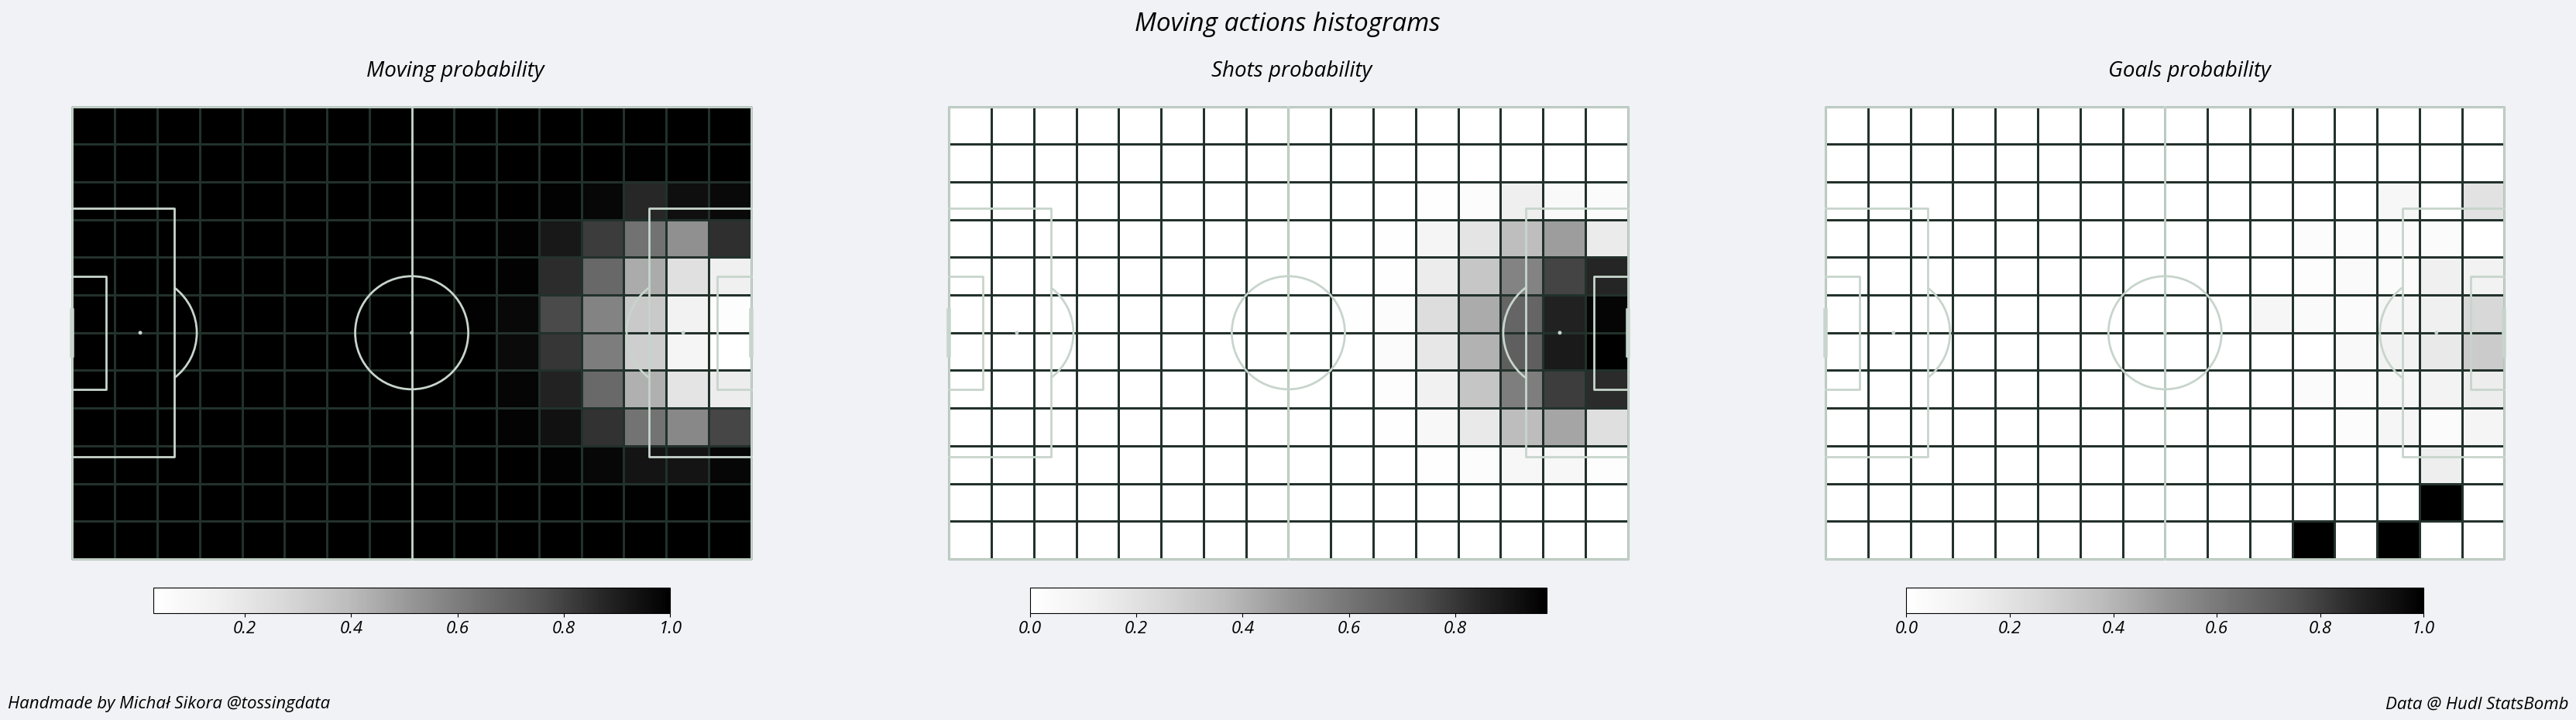

In [ ]:
# Moving, shots and goals probabilities vizualisation
moving_prob_all = [women_moving_prob, women_shot_prob, women_goals_prob]

pitch = Pitch(pitch_color='#f0f2f5',
              line_color='#c7d5cc',
              half=False,
              pitch_type='statsbomb',
              line_zorder=2,
              axis=False,
              tick=False
              )

fig, axs = pitch.grid(ncols=3,
                      nrows=1,
                      grid_height=0.85,
                      title_height=0.11,
                      axis=False,
                      endnote_height=0.04,
                      title_space=0,
                      endnote_space=0
                      )

# Params
fig.set_facecolor('#f0f2f5')
edgecolor='#22312b'
color='#22312b'
alpha=0.6
c='#000000'
tick_font_size = 16

# Colorbar ticks params
params = {'xtick.color' : '#000000',
          'ytick.color' : '#000000'}

plt.rcParams.update(params)

for idx, ax in enumerate(axs['pitch'].flatten()):
  for i, ele in enumerate(moving_prob_all):
    if idx == i:
      move['statistic'] = ele
      pcm = pitch.heatmap(move, cmap='Greys', edgecolor=edgecolor, ax=ax)
      cbar = plt.colorbar(pcm, ax=ax, shrink=0.60, location='bottom', pad=0.01)
      cbar.ax.tick_params(labelsize=tick_font_size)

# Title
axs['title'].text(x=0.44, y=0.70, s="Moving actions histograms", fontsize=24, c=c)

axs['title'].text(x=0.14, y=0.10, s="Moving probability", fontsize=20, c=c)

axs['title'].text(x=0.47, y=0.10, s="Shots probability", fontsize=20, c=c)

axs['title'].text(x=0.82,y=0.10, s="Goals probability", fontsize=20, c=c)

# Endnote
axs['endnote'].text(0, 0., 'Handmade by Michał Sikora @tossingdata',
                    fontsize=16,
                    va='center',
                    ha='left',
                    c=c
                    )

axs['endnote'].text(1.0, 0., 'Data @ Hudl StatsBomb',
                    fontsize=16,
                    va='center',
                    ha='right',
                    c=c
                    )
plt.show()

#### **Calculation of the model transition matrix** ###

In [ ]:
def xT_calculation(passes):

  """Return transition matrix with values necessary for xT model.

  Args:
    passes (df): df all_passes_clean (contain clean data from Women Super League season 2018/2019 and 2019/2020)

  Returns:
    np.array: array with xT values

  """

  # Code obtained from soccermatics free course https://soccermatics.readthedocs.io/en/latest/gallery/lesson4/plot_ExpectedThreat.html
  # Columns with two values start and end pass sector

  passes["start_sector"] = passes.apply(lambda row: tuple([i[0] for i in binned_statistic_2d(np.ravel(row.x), np.ravel(row.y),
                                                                values = "None", statistic="count",
                                                                bins=(16, 12), range=[[0, 120], [0, 80]],
                                                                expand_binnumbers=True)[3]]), axis = 1)

  passes["end_sector"] = passes.apply(lambda row: tuple([i[0] for i in binned_statistic_2d(np.ravel(row.end_x), np.ravel(row.end_y),
                                                                values = "None", statistic="count",
                                                                bins=(16, 12), range=[[0, 120], [0, 80]],
                                                                expand_binnumbers=True)[3]]), axis = 1)

  # Numer of start sector occuranece in df
  df_count_starts_women_passes = all_passes_clean.groupby(["start_sector"])["id"].count().reset_index()
  df_count_starts_women_passes.rename(columns = {'id':'count_starts'}, inplace=True)

  # Trasition matrix with calculate values
  transition_matrices_women = []

  for i, row in df_count_starts_women_passes.iterrows():
    start_sector = row['start_sector']
    count_starts = row['count_starts']
    # All events that started in this sector
    this_sector = all_passes_clean.loc[all_passes_clean["start_sector"] == start_sector]
    df_cound_ends_women_passes = this_sector.groupby(["end_sector"])["id"].count().reset_index()
    df_cound_ends_women_passes.rename(columns = {'id':'count_ends'}, inplace=True)
    T_matrix = np.zeros((12, 16))

    for j, row2 in df_cound_ends_women_passes.iterrows():
      end_sector = row2["end_sector"]
      value = row2["count_ends"]
      T_matrix[end_sector[1] - 1][end_sector[0] - 1] = value
    T_matrix = T_matrix / count_starts
    transition_matrices_women.append(T_matrix)

  return transition_matrices_women

In [ ]:
transition_matrices_women = xT_calculation(all_passes_clean)

In [ ]:
def xT_model(transition_matrices):

  """Return matrix with xT values in 12 rows and 16 columns.

  Args:
    transition_matrices (np.array): array contain values for xT model calculations

  Returns:
    np.array: array with xT values.

  """
  transition_matrices_array_women = np.array(transition_matrices_women)

  # Fully transition matrix after 5 iteration
  xT_women = np.zeros((12, 16))

  for i in range(5):
    shoot_expected_payoff = women_goals_prob*women_shot_prob
    move_expected_payoff = women_moving_prob*(np.sum(np.sum(transition_matrices_array_women*xT_women, axis = 2), axis = 1).reshape(16,12).T)
    xT_women = shoot_expected_payoff + move_expected_payoff

  return xT_women

In [ ]:
xT_women = xT_model(transition_matrices_women)

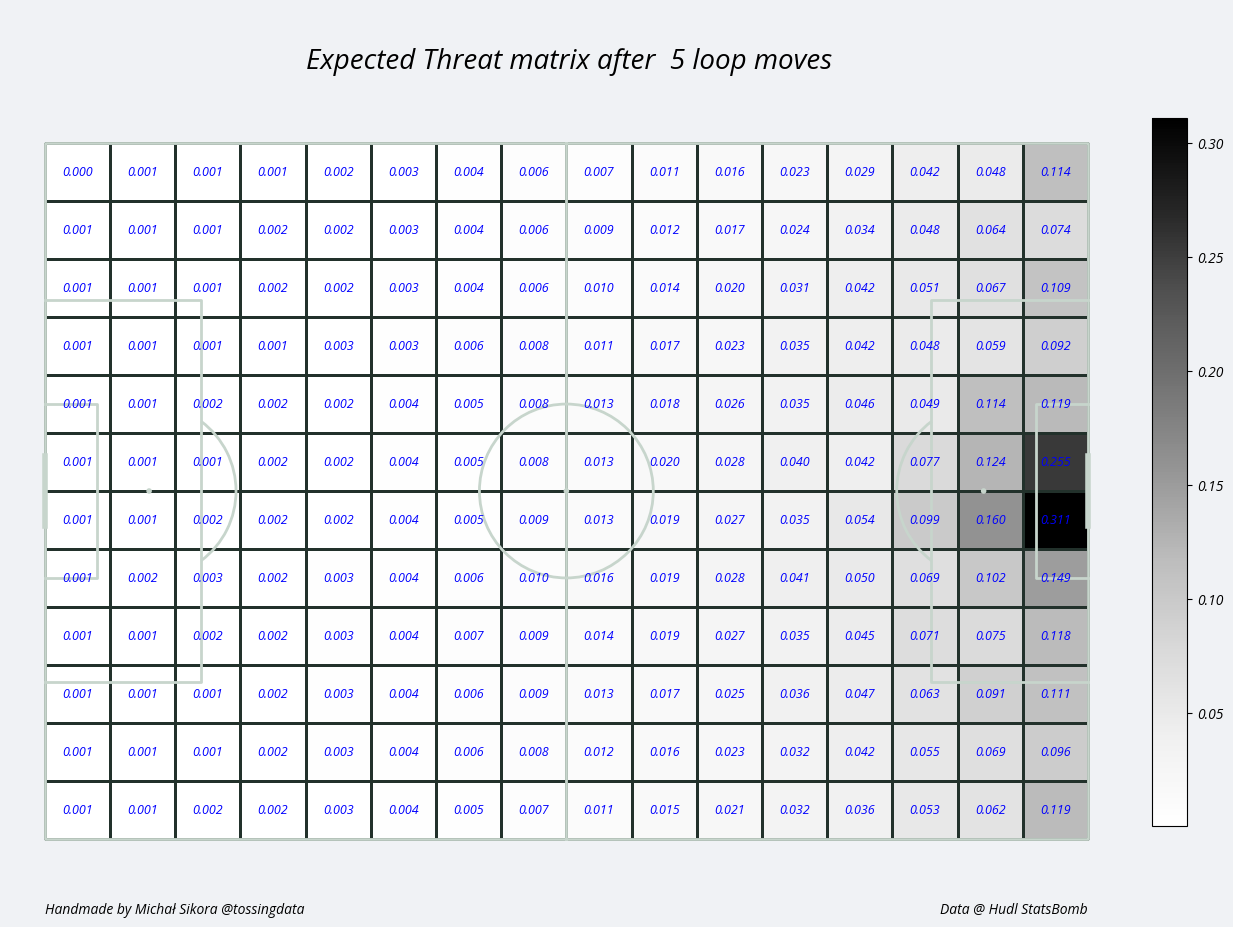

In [ ]:
# xT model with 12 rows and 16 columns pitch values vizualisation

pitch = Pitch(pitch_color='#f0f2f5',
              line_color='#c7d5cc',
              half = False, pitch_type='statsbomb',
              line_zorder=2,
              axis=False,
              tick=False
              )

fig, axs = pitch.grid(grid_height=0.85,
                      title_height=0.11,
                      axis=False,
                      endnote_height=0.04,
                      title_space=0,
                      endnote_space=0
                      )

# Params
fig.set_facecolor('#f0f2f5')
edgecolor='#22312b'
color='#22312b'
alpha=0.6
c='#000000'
tick_font_size = 18

# Colorbar ticks params
params = {'xtick.color' : '#000000',
          'ytick.color' : '#000000'}

women_goals_bin['statistic'] = xT_women
pcm  = pitch.heatmap(women_goals_bin, cmap='Greys', edgecolor=edgecolor, ax=axs['pitch'])

labels = pitch.label_heatmap(women_goals_bin,
                             color='blue',
                             fontsize=9,
                             ax=axs['pitch'],
                             ha='center', va='center',
                             str_format="{0:,.3f}", zorder=3
                             )

# Legend
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)

# Title
axs['title'].text(x=0.25,
                  y=0.40,
                  s="Expected Threat matrix after 5 loop moves",
                  fontsize=20,
                  c=c
                  )

# Endnote
axs['endnote'].text(0., 0., 'Handmade by Michał Sikora @tossingdata',
                    fontsize=10,
                    va='center',
                    ha='left',
                    c=c
                    )

axs['endnote'].text(1.0, 0., 'Data @ Hudl StatsBomb',
                    fontsize=10,
                    va='center',
                    ha='right',
                    c=c
                    )

plt.show()

#### **xT model matrix storage** ###

In [ ]:
def xT_to_csv(xT_matrix):

  """Return csv file with 12 rows and 16 columns xT values as pitch projection.

  Args:
    np.array (array): array contain xT values.

  Returns:
    df: df with xT values.

  """
  df = pd.DataFrame(xT_matrix)

  df.to_csv('xT.csv', index=False, header=False)

  return df

In [ ]:
xT_to_csv(xT_women)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.000494,0.000632,0.001039,0.001150,0.001792,0.002569,0.003646,0.005514,0.007419,0.011011,0.015841,0.023251,0.028726,0.041981,0.048114,0.113549
1,0.000562,0.000684,0.000989,0.001523,0.001834,0.002674,0.003816,0.006183,0.009465,0.011880,0.017414,0.024202,0.033518,0.047912,0.064209,0.073789
2,0.000518,0.000647,0.000834,0.001624,0.002100,0.003340,0.004173,0.006417,0.009624,0.014295,0.020449,0.031154,0.042165,0.051234,0.067031,0.108770
3,0.000690,0.000775,0.001235,0.001452,0.002517,0.003284,0.005577,0.007897,0.011463,0.016537,0.023416,0.034871,0.042423,0.048447,0.058858,0.092154
4,0.000975,0.001028,0.001702,0.001603,0.002222,0.004043,0.005322,0.008204,0.013176,0.018318,0.026334,0.034966,0.046245,0.049231,0.114336,0.119385
5,0.000842,0.001040,0.001375,0.001709,0.002307,0.003600,0.005332,0.007975,0.012715,0.019738,0.027633,0.039957,0.041527,0.077324,0.124486,0.254501
6,0.001266,0.001148,0.001503,0.001901,0.002421,0.004232,0.005042,0.008856,0.013387,0.019067,0.026633,0.035221,0.053624,0.098838,0.159573,0.310753
7,0.001327,0.001620,0.002617,0.001881,0.002939,0.004398,0.006049,0.009533,0.015800,0.019280,0.028490,0.041384,0.049991,0.068784,0.101998,0.149095
8,0.001406,0.001203,0.002445,0.001924,0.003221,0.004118,0.007128,0.008634,0.014165,0.018530,0.027314,0.035000,0.045411,0.071495,0.075079,0.118419
9,0.001051,0.001132,0.001297,0.002001,0.003021,0.004134,0.006357,0.008870,0.012699,0.017216,0.024631,0.036374,0.046974,0.062947,0.091197,0.110981
